In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib as plt
import seaborn as sns
from scripts import style
style.mpl_apply()

In [13]:
y1 = pd.read_csv('results/yhat construction/em/Yhat_EM_Temp=0.01.csv')
y2 = pd.read_csv('results/yhat construction/yolo/Yhat_IntegerProgramming.csv')

y1 = y1.set_index('SamplingOperations_code')
y2 = y2.set_index('SamplingOperations_code')

In [14]:
y1 = y1[['y_hat']]
y1 = y1.rename(columns={"y_hat": "IBD_EQR_Status"})
y2 = y2.rename(columns={"y_hat": "IBD_EQR_Status"})

In [9]:
cm = confusion_matrix(y1, y2)

In [15]:
y_true = y1['IBD_EQR_Status']
y_pred = y2['IBD_EQR_Status']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f'"Coincidence": {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

"Coincidence": 0.8748
Precision: 0.8983
Recall: 0.8748
F1 Score: 0.8833


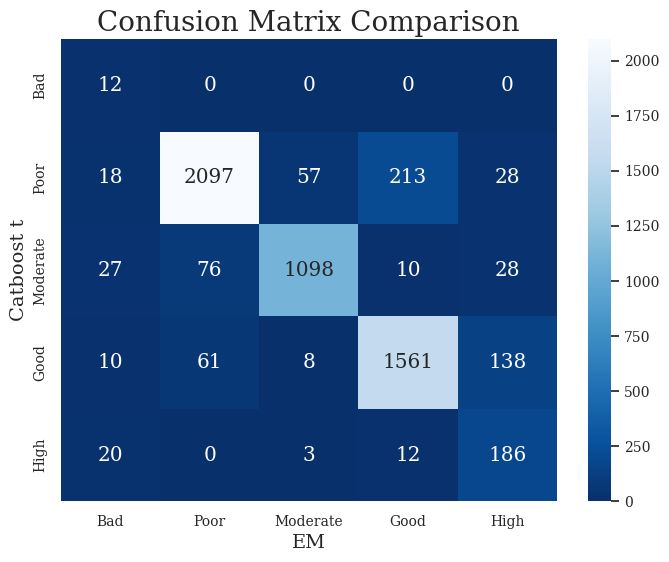

In [16]:
# plot the confusion matrix
import matplotlib.pyplot as plt
labels = ['Bad', 'Poor', 'Moderate', 'Good', 'High']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r', xticklabels=labels, yticklabels=labels)
plt.xlabel('EM')
plt.ylabel('Catboost t')
plt.title('Confusion Matrix Comparison')
plt.show()